Generating synthetic data...
Data shape: X=(500, 5), Y=(500, 4)
Response prevalence: [0.488 0.45  0.528 0.62 ]

Fitting Logistic Reduced Rank Regression...
Iteration 0: Loss = 1368.3733
Iteration 10: Loss = 930.6059
Iteration 20: Loss = 923.3991
Iteration 30: Loss = 921.3809
Iteration 40: Loss = 920.5823

Overall Accuracy: 0.750

Saved: lrrr_convergence.png

Creating hybrid triplot...
Saved: lrrr_triplot.png

INTERPRETATION GUIDE

1. GRAY POINTS: Individual observations in reduced 2D space

2. BLUE ARROWS: Predictor variables
   - Direction shows relationship to dimensions
   - Length shows strength of relationship

3. GREEN LINES: Response variables (hybrid representation)
   - SOLID part: discriminatory power (longer = better discrimination)
   - Endpoints: category points (circle=No, triangle=Yes)
   - Dotted extension: full axis with probability markers
   - Label position: high probability direction

4. INTERPRETATION:
   - Sharp angle between predictor & response: strong positive

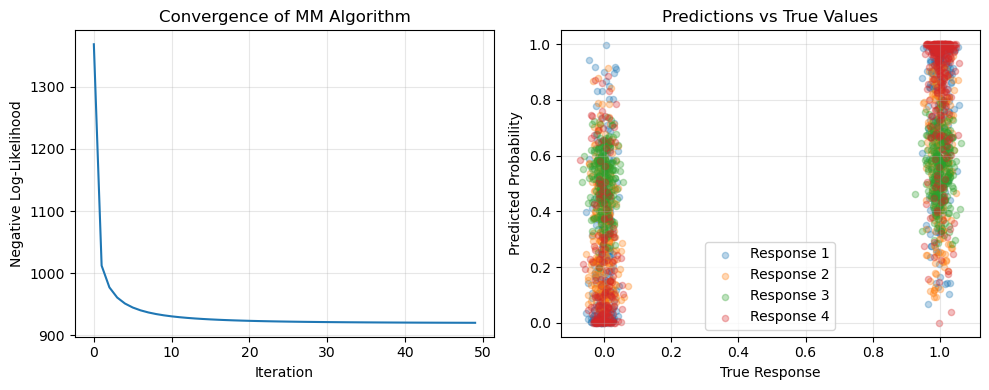

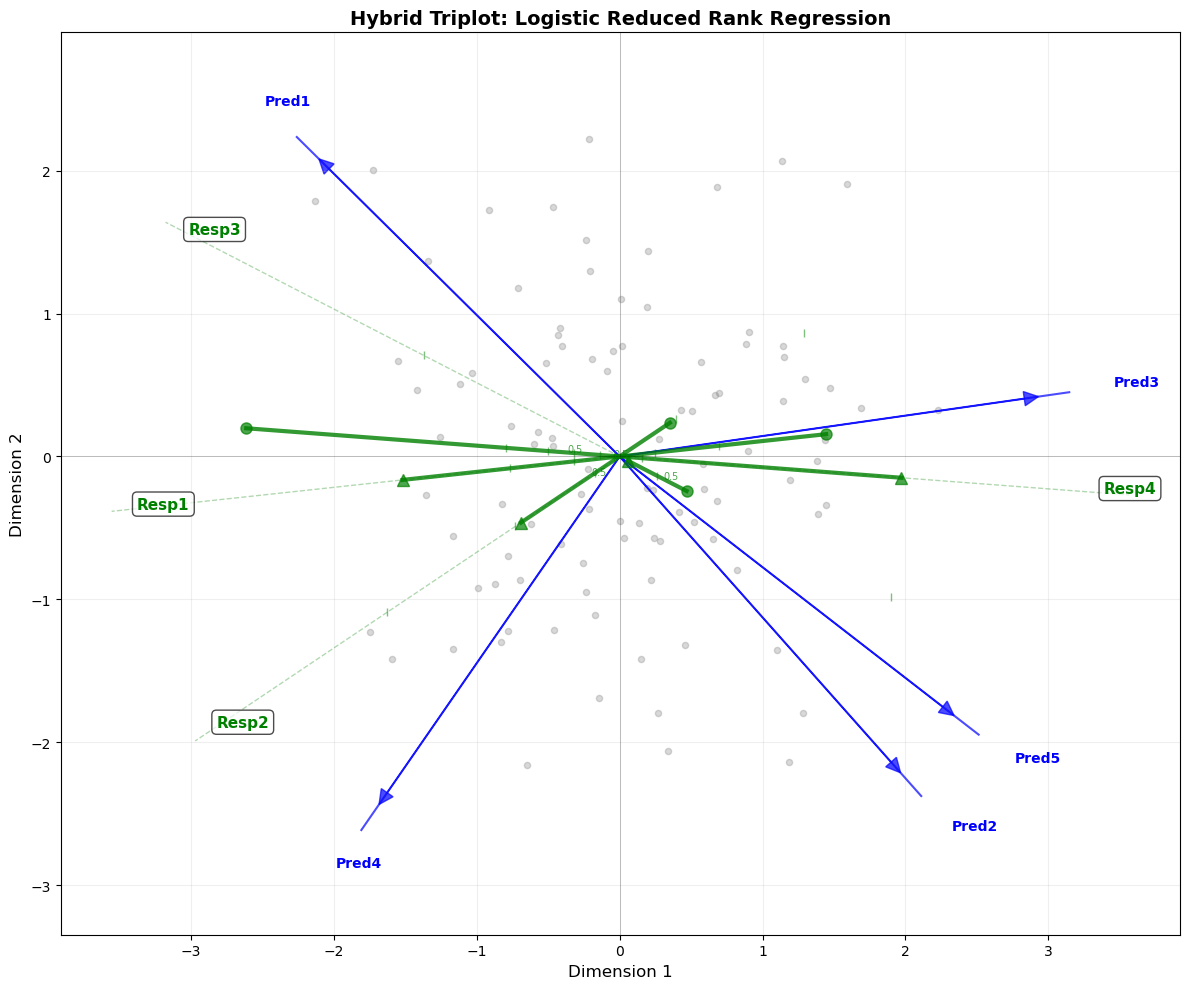

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class LogisticReducedRankRegression:
    """
    Logistic Reduced Rank Regression using MM Algorithm
    
    Parameters:
    -----------
    n_components : int
        Number of dimensions (rank) for the reduced representation
    max_iter : int
        Maximum number of iterations
    tol : float
        Convergence tolerance
    """
    
    def __init__(self, n_components=2, max_iter=100, tol=1e-6):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.B = None  # Predictor loadings
        self.V = None  # Response loadings
        self.m = None  # Intercepts
        self.loss_history = []
        
    def _sigmoid(self, x):
        """Compute sigmoid function safely"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def _compute_theta(self, X):
        """Compute log-odds: θ = m' + XBV'"""
        N = X.shape[0]
        theta = np.outer(np.ones(N), self.m) + X @ self.B @ self.V.T
        return theta
    
    def _compute_loss(self, Y, theta):
        """Compute negative log-likelihood"""
        q = 2 * Y - 1  # Convert 0/1 to -1/+1
        # Loss = -sum(log(1/(1 + exp(-q*theta))))
        loss = -np.sum(np.log(self._sigmoid(q * theta)))
        return loss
    
    def fit(self, X, Y):
        """
        Fit the Logistic Reduced Rank Regression model
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_predictors)
            Predictor variables
        Y : array-like, shape (n_samples, n_responses)
            Binary response variables (0 or 1)
        """
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float)
        
        N, P = X.shape
        N, R = Y.shape
        S = self.n_components
        
        # Initialize parameters
        # Start with simple initialization
        self.m = np.log((Y.mean(axis=0) + 0.01) / (1 - Y.mean(axis=0) + 0.01))
        
        # Initialize B and V with small random values
        self.B = np.random.randn(P, S) * 0.01
        self.V = np.random.randn(R, S) * 0.01
        
        # Precompute (X'X)^(-1/2) for efficiency
        XtX = X.T @ X
        eigvals, eigvecs = np.linalg.eigh(XtX)
        XtX_inv_sqrt = eigvecs @ np.diag(1/np.sqrt(eigvals + 1e-10)) @ eigvecs.T
        
        # MM Algorithm iterations
        for iteration in range(self.max_iter):
            # Compute current predictions
            theta = self._compute_theta(X)
            pi = self._sigmoid(theta)
            
            # Compute loss
            loss = self._compute_loss(Y, theta)
            self.loss_history.append(loss)
            
            # Check convergence
            if iteration > 0:
                if abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                    print(f"Converged at iteration {iteration}")
                    break
            
            # Step 1: Compute working responses
            Z = theta + 4 * (Y - pi)
            
            # Step 2: Update intercepts
            self.m = np.mean(Z - X @ self.B @ self.V.T, axis=0)
            
            # Step 3: Center Z
            Z_centered = Z - np.outer(np.ones(N), self.m)
            
            # Step 4: Generalized SVD
            # Compute (X'X)^(-1/2) X' Z_centered
            M = XtX_inv_sqrt @ X.T @ Z_centered
            
            # Standard SVD
            U, s, Vt = svd(M, full_matrices=False)
            
            # Step 5: Update B and V
            self.B = np.sqrt(N) * XtX_inv_sqrt @ U[:, :S]
            self.V = (1/np.sqrt(N)) * Vt.T[:, :S] @ np.diag(s[:S])
            
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Loss = {loss:.4f}")
        
        return self
    
    def predict_proba(self, X):
        """
        Predict probabilities for response variables
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_predictors)
            Predictor variables
            
        Returns:
        --------
        proba : array, shape (n_samples, n_responses)
            Predicted probabilities
        """
        theta = self._compute_theta(X)
        return self._sigmoid(theta)
    
    def predict(self, X, threshold=0.5):
        """Predict binary outcomes"""
        return (self.predict_proba(X) > threshold).astype(int)
    
    def get_object_scores(self, X):
        """Get object scores: u_i = B' x_i"""
        return X @ self.B
    
    def plot_hybrid_triplot(self, X, Y, predictor_names=None, response_names=None,
                           figsize=(12, 10), show_objects=True, n_objects_show=100):
        """
        Create hybrid triplot visualization
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_predictors)
            Predictor variables
        Y : array-like, shape (n_samples, n_responses)
            Binary response variables
        predictor_names : list of str
            Names of predictor variables
        response_names : list of str
            Names of response variables
        """
        if self.n_components != 2:
            raise ValueError("Triplot only available for 2D models")
        
        # Get object scores
        U = self.get_object_scores(X)
        
        # Sample objects for clarity if too many
        if show_objects and len(U) > n_objects_show:
            idx = np.random.choice(len(U), n_objects_show, replace=False)
            U_plot = U[idx]
        else:
            U_plot = U
        
        # Create figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # Plot objects
        if show_objects:
            ax.scatter(U_plot[:, 0], U_plot[:, 1], c='gray', alpha=0.3, 
                      s=20, label='Objects')
        
        # Plot predictor variable axes
        scale_pred = np.max(np.abs(U)) * 1.2
        for p in range(self.B.shape[0]):
            direction = self.B[p, :]
            length = np.linalg.norm(direction)
            if length > 0.01:  # Only plot if substantial
                direction = direction / length * scale_pred * 0.8
                
                # Draw axis
                ax.plot([0, direction[0]], [0, direction[1]], 
                       'b-', linewidth=1.5, alpha=0.7)
                ax.arrow(0, 0, direction[0]*0.9, direction[1]*0.9,
                        head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.7)
                
                # Label
                name = predictor_names[p] if predictor_names else f'X{p+1}'
                ax.text(direction[0]*1.1, direction[1]*1.1, name, 
                       fontsize=10, color='blue', fontweight='bold')
        
        # Plot response variable axes (hybrid style)
        for r in range(self.V.shape[0]):
            v_r = self.V[r, :]
            length = np.linalg.norm(v_r)
            
            if length < 0.01:
                continue
            
            # Compute category points for Type D representation
            k_r = -v_r / 2  # K matrix
            l_r = self.m[r] * k_r / (2 * np.sum(k_r**2))  # L matrix
            
            w_r0 = l_r + k_r  # Category 0 point
            w_r1 = l_r - k_r  # Category 1 point
            
            # Draw axis
            direction = v_r / length
            
            # Extend axis (dotted line)
            max_extent = scale_pred * 0.9
            ax.plot([0, direction[0]*max_extent], [0, direction[1]*max_extent],
                   'g--', linewidth=1, alpha=0.3)
            
            # Draw solid part between category points (discriminatory power)
            ax.plot([w_r0[0], w_r1[0]], [w_r0[1], w_r1[1]], 
                   'g-', linewidth=3, alpha=0.8)
            
            # Mark category points
            ax.plot(w_r0[0], w_r0[1], 'go', markersize=8, alpha=0.7)
            ax.plot(w_r1[0], w_r1[1], 'g^', markersize=8, alpha=0.7)
            
            # Add probability markers along axis
            for prob in [0.1, 0.3, 0.5, 0.7, 0.9]:
                lambda_val = np.log(prob / (1 - prob)) - self.m[r]
                marker_pos = lambda_val * v_r / np.sum(v_r**2)
                
                if np.linalg.norm(marker_pos) < max_extent:
                    ax.plot(marker_pos[0], marker_pos[1], 'g|', 
                           markersize=6, alpha=0.5)
                    if prob == 0.5:
                        ax.text(marker_pos[0]*1.15, marker_pos[1]*1.15, 
                               f'{prob:.1f}', fontsize=7, color='green', alpha=0.7)
            
            # Label (on the high probability side)
            label_pos = direction * max_extent * 0.95
            name = response_names[r] if response_names else f'Y{r+1}'
            ax.text(label_pos[0], label_pos[1], name, 
                   fontsize=11, color='green', fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
        ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
        ax.set_xlabel('Dimension 1', fontsize=12)
        ax.set_ylabel('Dimension 2', fontsize=12)
        ax.set_title('Hybrid Triplot: Logistic Reduced Rank Regression', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.2)
        ax.axis('equal')
        
        plt.tight_layout()
        return fig, ax


# ============= DEMONSTRATION WITH SYNTHETIC DATA =============

def generate_synthetic_data(n_samples=500, n_predictors=5, n_responses=4, 
                           n_components=2, noise=0.5):
    """Generate synthetic data for demonstration"""
    np.random.seed(42)
    
    # Generate predictors
    X = np.random.randn(n_samples, n_predictors)
    
    # True underlying structure
    B_true = np.random.randn(n_predictors, n_components)
    V_true = np.random.randn(n_responses, n_components)
    m_true = np.random.randn(n_responses) * 0.5
    
    # Compute probabilities
    theta = np.outer(np.ones(n_samples), m_true) + X @ B_true @ V_true.T
    theta += np.random.randn(n_samples, n_responses) * noise
    prob = 1 / (1 + np.exp(-theta))
    
    # Generate binary responses
    Y = (np.random.rand(n_samples, n_responses) < prob).astype(int)
    
    return X, Y


# Generate data
print("Generating synthetic data...")
X, Y = generate_synthetic_data(n_samples=500, n_predictors=5, n_responses=4)

print(f"Data shape: X={X.shape}, Y={Y.shape}")
print(f"Response prevalence: {Y.mean(axis=0)}")

# Fit model
print("\nFitting Logistic Reduced Rank Regression...")
model = LogisticReducedRankRegression(n_components=2, max_iter=50, tol=1e-6)
model.fit(X, Y)

# Predictions
Y_pred_proba = model.predict_proba(X)
Y_pred = model.predict(X)

# Evaluate
accuracy = np.mean(Y == Y_pred)
print(f"\nOverall Accuracy: {accuracy:.3f}")

# Plot loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Negative Log-Likelihood')
plt.title('Convergence of MM Algorithm')
plt.grid(True, alpha=0.3)

# Plot predictions vs actual
plt.subplot(1, 2, 2)
for r in range(Y.shape[1]):
    plt.scatter(Y[:, r] + np.random.randn(len(Y))*0.02, 
               Y_pred_proba[:, r], alpha=0.3, s=20, label=f'Response {r+1}')
plt.xlabel('True Response')
plt.ylabel('Predicted Probability')
plt.title('Predictions vs True Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lrrr_convergence.png', dpi=150, bbox_inches='tight')
print("\nSaved: lrrr_convergence.png")

# Create hybrid triplot
print("\nCreating hybrid triplot...")
predictor_names = [f'Pred{i+1}' for i in range(X.shape[1])]
response_names = [f'Resp{i+1}' for i in range(Y.shape[1])]

fig, ax = model.plot_hybrid_triplot(X, Y, 
                                    predictor_names=predictor_names,
                                    response_names=response_names,
                                    show_objects=True)
plt.savefig('lrrr_triplot.png', dpi=150, bbox_inches='tight')
print("Saved: lrrr_triplot.png")

print("\n" + "="*50)
print("INTERPRETATION GUIDE")
print("="*50)
print("""
1. GRAY POINTS: Individual observations in reduced 2D space

2. BLUE ARROWS: Predictor variables
   - Direction shows relationship to dimensions
   - Length shows strength of relationship

3. GREEN LINES: Response variables (hybrid representation)
   - SOLID part: discriminatory power (longer = better discrimination)
   - Endpoints: category points (circle=No, triangle=Yes)
   - Dotted extension: full axis with probability markers
   - Label position: high probability direction

4. INTERPRETATION:
   - Sharp angle between predictor & response: strong positive association
   - ~90° angle: weak association
   - Obtuse angle: negative association
   - Project object points onto response axes to read probabilities
   - Closer endpoint determines most likely category
""")

plt.show()

📥 Loading UCI Drug Consumption dataset...
✔ Loaded 1885 samples, 8 predictors, 11 responses
🔧 X scaled (mean=0, std=1).

🚀 Fitting LRRR model...
Iteration 0: Loss = 13094.1568
Iteration 10: Loss = 11061.0682
Iteration 20: Loss = 11060.7234
Iteration 30: Loss = 11060.7197
Converged at iteration 38

📐 Computing Q_r metrics...
  Qr(Amphetamine): 0.980
  Qr(Benzos): 0.917
  Qr(Cannabis): 0.982
  Qr(Cocaine): 0.957
  Qr(Ecstasy): 0.972
  Qr(Ketamine): 0.951
  Qr(LegalHighs): 0.993
  Qr(LSD): 0.939
  Qr(Methadone): 0.921
  Qr(Mushrooms): 0.967
  Qr(Nicotine): 0.963

📊 Plotting hybrid triplot...


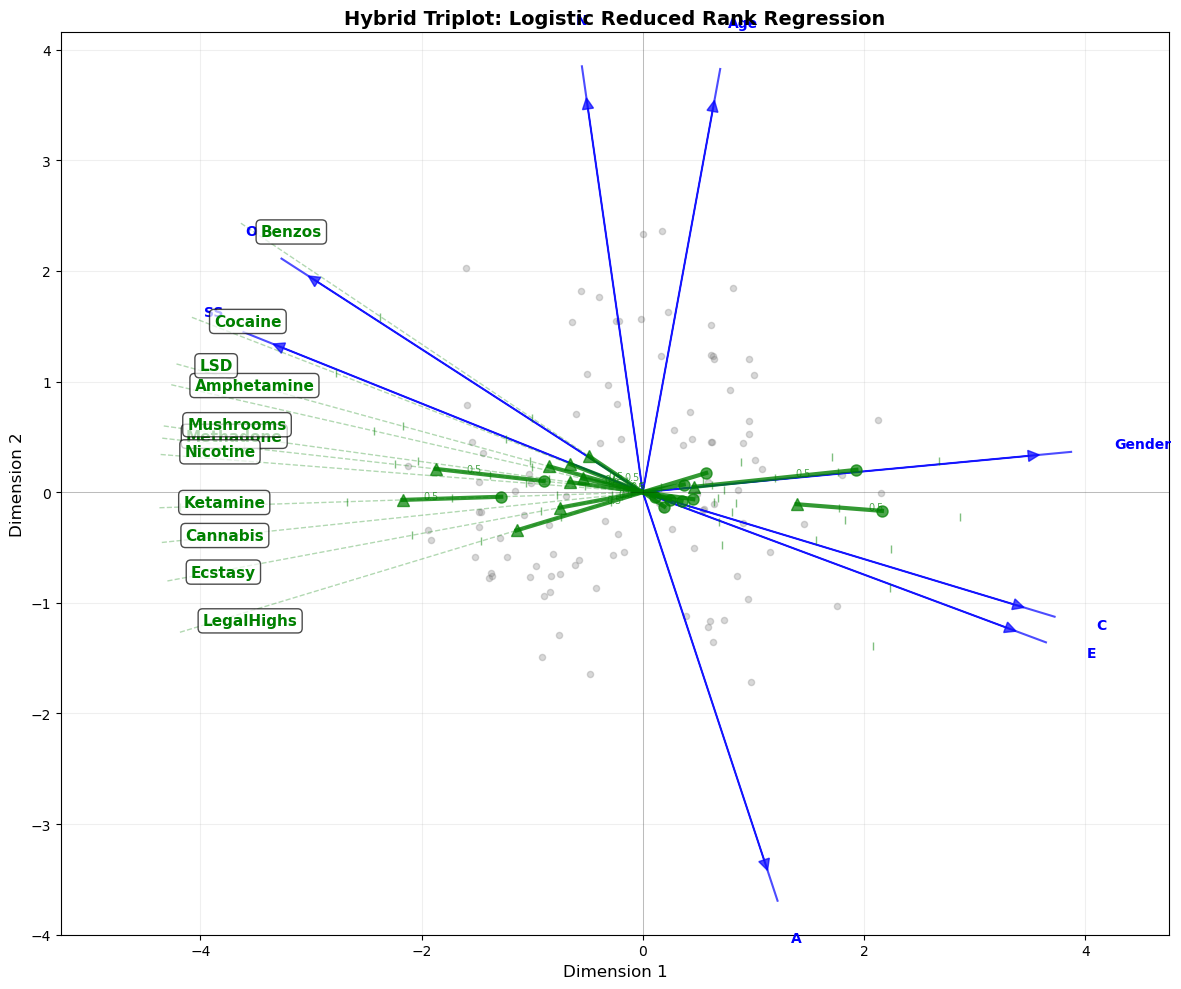

In [5]:
# ==============================================================
# ENHANCED DATA PIPELINE + MISSING DATA HANDLING + QR METRICS
# ==============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer


###############################################
# 1️⃣ SELECT DATASET
###############################################
DATASET = "drug"     # options: "drug", "census"
SCALE_X = True        # scale predictors
###############################################


# --------------------------------------------------------
# UTILITY: IMPUTE MISSING VALUES
# --------------------------------------------------------
def impute_numeric(df):
    """Median imputation for numeric columns."""
    imp = SimpleImputer(strategy="median")
    return pd.DataFrame(imp.fit_transform(df), columns=df.columns)

def impute_categorical(df):
    """Most-frequent imputation for categorical columns."""
    imp = SimpleImputer(strategy="most_frequent")
    return pd.DataFrame(imp.fit_transform(df), columns=df.columns)


# --------------------------------------------------------
# LOAD + CLEAN DRUG DATA
# --------------------------------------------------------
def load_drug_data():
    print("📥 Loading UCI Drug Consumption dataset...")

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00373/drug_consumption.data"

    cols = ["ID", "Age", "Gender", "Education", "Country", "Ethnicity",
            "N", "E", "O", "A", "C", "Imp", "SS",
            "Alcohol", "Amphetamine", "Amyl", "Benzos", "Caffeine", "Cannabis",
            "Chocolate", "Cocaine", "Crack", "Ecstasy", "Heroin", "Ketamine",
            "LegalHighs", "LSD", "Methadone", "Mushrooms", "Nicotine",
            "Semer", "VSA"]

    df = pd.read_csv(url, names=cols)

    # Numeric predictors (paper uses Age, Gender, N, E, O, A, C, SS)
    X_cols = ["Age", "Gender", "N", "E", "O", "A", "C", "SS"]
    X = df[X_cols].astype(float)

    # Impute missing numeric values
    X = impute_numeric(X)

    # Drug responses (11 binary targets)
    Y_cols = ["Amphetamine", "Benzos", "Cannabis", "Cocaine", "Ecstasy",
              "Ketamine", "LegalHighs", "LSD", "Methadone", "Mushrooms", "Nicotine"]

    def binarize(s):
        return 0 if s == "CL0" else 1

    Y = df[Y_cols].applymap(binarize)

    # Impute missing response data as non-use (0)
    Y = Y.fillna(0)

    print(f"✔ Loaded {X.shape[0]} samples, {X.shape[1]} predictors, {Y.shape[1]} responses")
    return X.values, Y.values, X_cols, Y_cols



# --------------------------------------------------------
# LOAD + CLEAN CENSUS DATA
# --------------------------------------------------------
def load_census_data():
    print("📥 Loading Census Income dataset...")

    cols = ["age","workclass","fnlwgt","education","education-num","marital-status",
            "occupation","relationship","race","sex","capital-gain","capital-loss",
            "hours-per-week","native-country","income"]

    df = pd.read_csv(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
        names=cols, na_values="?", skipinitialspace=True
    )

    # Separate features & target
    Y = (df["income"].str.strip() == ">50K").astype(int).to_frame()

    X_raw = df.drop("income", axis=1)

    # Separate numeric & categorical
    num_cols = X_raw.select_dtypes(include=np.number).columns
    cat_cols = X_raw.select_dtypes(exclude=np.number).columns

    X_num = impute_numeric(X_raw[num_cols])
    X_cat = impute_categorical(X_raw[cat_cols])

    # One-hot encode categoricals
    X = pd.get_dummies(pd.concat([X_num, X_cat], axis=1), drop_first=True)

    # Impute missing responses as 0
    Y = Y.fillna(0)

    print(f"✔ Loaded {X.shape[0]} rows, {X.shape[1]} predictors, 1 response")
    return X.values, Y.values, list(X.columns), ["income > 50K"]


# --------------------------------------------------------
# 2️⃣ LOAD DATASET
# --------------------------------------------------------
if DATASET == "drug":
    X, Y, predictor_names, response_names = load_drug_data()
else:
    X, Y, predictor_names, response_names = load_census_data()



# --------------------------------------------------------
# 3️⃣ SCALE X (recommended)
# --------------------------------------------------------
if SCALE_X:
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    print("🔧 X scaled (mean=0, std=1).")



# --------------------------------------------------------
# 4️⃣ FIT LOGISTIC REDUCED RANK REGRESSION
# --------------------------------------------------------
model = LogisticReducedRankRegression(
    n_components=2,
    max_iter=80,
    tol=1e-6
)

print("\n🚀 Fitting LRRR model...")
model.fit(X, Y)



# --------------------------------------------------------
# 5️⃣ QUALITY-OF-REPRESENTATION  (Qr)
# --------------------------------------------------------
def compute_Qr(model, X, Y):
    """
    Computes Q_r for each response variable:
    Qr = (D0 - Dr) / (D0 - D_logistic)
    """
    N, R = Y.shape
    Qr_list = []

    # Full model deviance pieces
    theta = model._compute_theta(X)
    pi = model._sigmoid(theta)
    eps = 1e-10

    for r in range(R):
        y = Y[:, r]
        th_r = theta[:, r]
        pi_r = pi[:, r]

        # Deviance for this column under reduced-rank model
        Dr = -2 * np.sum(y*np.log(pi_r+eps) + (1-y)*np.log(1-pi_r+eps))

        # Null deviance (intercept-only)
        p0 = y.mean()
        D0 = -2 * np.sum(y*np.log(p0+eps) + (1-y)*np.log(1-p0+eps))

        # Logistic regression deviance
        lr = LogisticRegression(max_iter=200)
        lr.fit(X, y)
        p_lr = lr.predict_proba(X)[:,1]
        D_lr = -2 * np.sum(y*np.log(p_lr+eps) + (1-y)*np.log(1-p_lr+eps))

        Qr = (D0 - Dr) / (D0 - D_lr + eps)
        Qr_list.append(Qr)

    return np.array(Qr_list)


print("\n📐 Computing Q_r metrics...")
Qr = compute_Qr(model, X, Y)

for name, q in zip(response_names, Qr):
    print(f"  Qr({name}): {q:.3f}")



# --------------------------------------------------------
# 6️⃣ HYBRID TRIPLOT
# --------------------------------------------------------
print("\n📊 Plotting hybrid triplot...")
fig, ax = model.plot_hybrid_triplot(
    X, Y,
    predictor_names=predictor_names,
    response_names=response_names
)
plt.show()
